<a href="https://colab.research.google.com/github/meiladewin/Praktikum-Struktur-Data/blob/main/StrukturData10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install network matplotlib

  Preparing metadata (setup.py) ... done
  Created wheel for network: filename=network-0.1-py3-none-any.whl size=3138 sha256=3795c2db64aa29d248a6b3eff2742ba9d3b52ffeada97cbea7bddbb987b3679b
  Stored in directory: /root/.cache/pip/wheels/e7/5a/7a/7f15bea66afb5505b9d10cc7bd8964cb77f0ce736df5b104c8
Successfully built network


2.Struktur Data Graf dan Algoritma

In [4]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    previous = {node: None for node in graph}
    queue = [(0, start)]

    while queue:
        current_distance, current_node = heapq.heappop(queue)

        if current_distance > distances[current_node]:
            continue

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(queue, (distance, neighbor))

    return distances, previous

3. Fungsi untuk Merekontruksi Jalur

In [5]:
def get_path(previous, target):
    path = []
    while target is not None:
        path.insert(0, target)
        target = previous[target]
    return path

4. Visualisasi dengan netowrkx dan matplotlib

In [6]:
def visualize_graph(graph, path=None):
    G = nx.DiGraph()
    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    pos = nx.spring_layout(G)
    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_weight='bold', arrows=True)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    # Garis tebal merah untuk jalur terpendek
    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

    plt.title("Visualisasi Graf dan Jalur Terpendek")
    plt.axis('off')
    plt.show()

5. Penggunaan Lengkap

Jarak dari A ke Z: 14
Jalur: A → B → D → E → Z


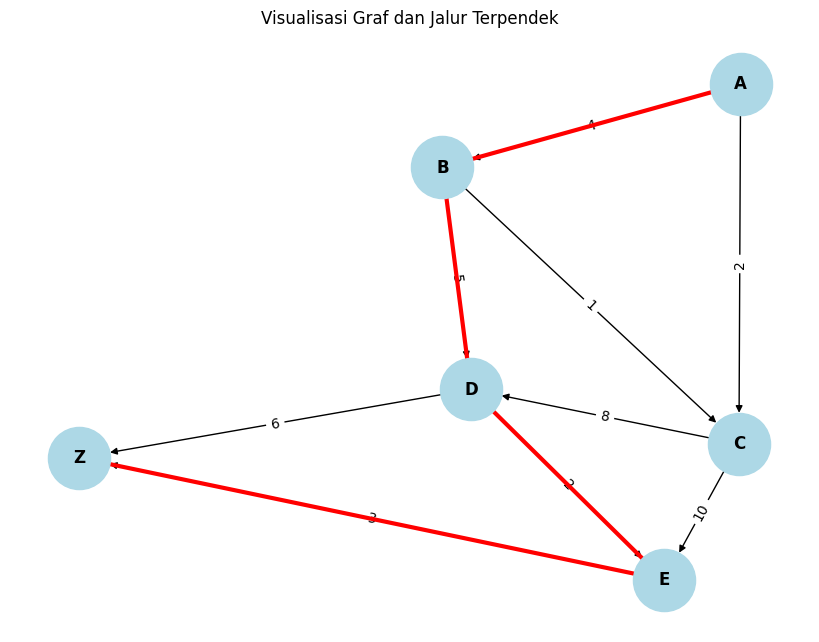

In [7]:
# Definisi graf
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'Z': {}
}

# Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths(graph, start_node)

# Rekonstruksi jalur
shortest_path = get_path(previous, end_node)
print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur: {' → '.join(shortest_path)}")

# Visualisasi
visualize_graph(graph, path=shortest_path)

Tugas 1: Modifikasi Graf Agar Memiliki Siklus

Jarak dari A ke Z: 14
Jarak: A->B->D->E->Z


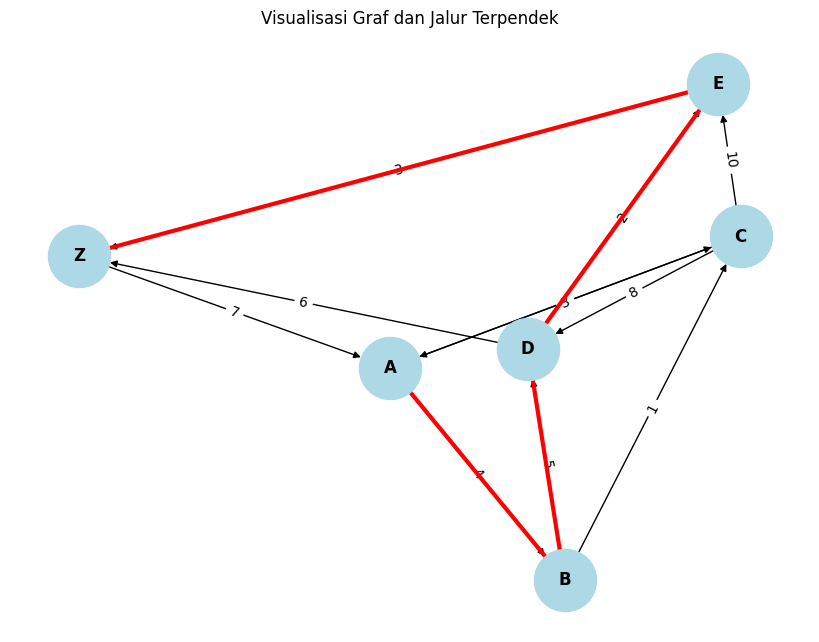

In [8]:
graph_cycle = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'A': 3, 'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'Z': {'A': 7}
}

distances2, previous2 = dijkstra_with_paths(graph_cycle, 'A')
path2 = get_path(previous2,'Z')

print(f'Jarak dari A ke Z: {distances2['Z']}')
print(f'Jarak: {'->'.join(path2)}')

visualize_graph(graph_cycle, path=path2)

Jarak dari A ke Z: 14
Jarak: A->B->D->E->Z


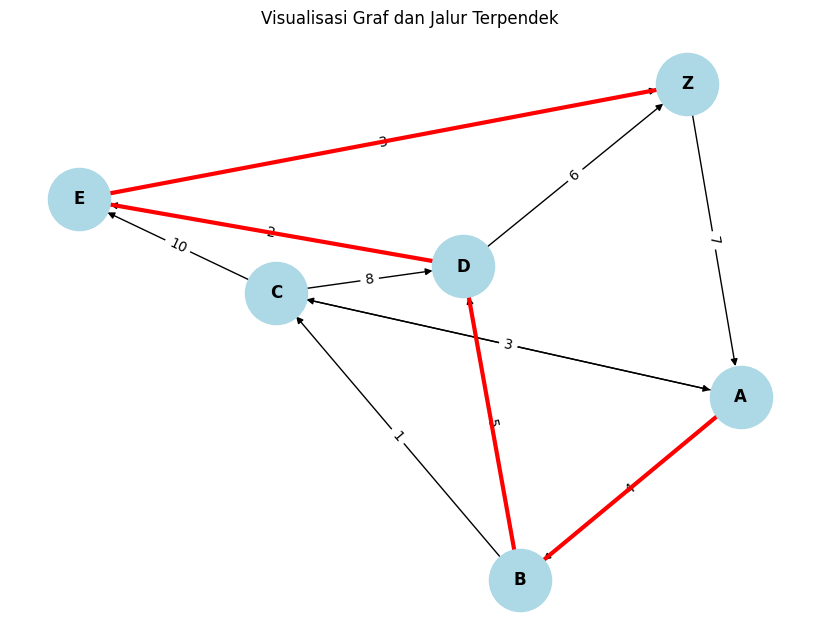

In [9]:
graph_cycle = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'A': 3, 'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'Z': {'A': 7}
}

distances2, previous2 = dijkstra_with_paths(graph_cycle, 'A')
path2 = get_path(previous2,'Z')

print(f'Jarak dari A ke Z: {distances2['Z']}')
print(f'Jarak: {'->'.join(path2)}')

visualize_graph(graph_cycle, path=path2)

Tugas 2: Tambah Simpul Baru dan Lihat Perubahan Jalur

Jarak dari W ke Z: 13
Jarak: W->B->D->E->Z

Jarak ke semua simpul W
 W -> A: 1
 W -> B: 3
 W -> C: 3
 W -> D: 8
 W -> E: 10
 W -> Z: 13
 W -> W: 0


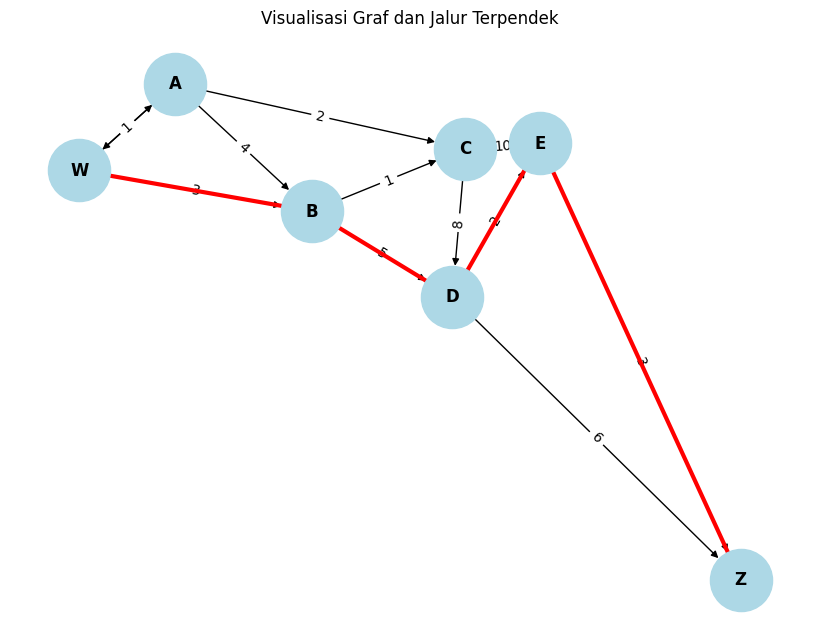

In [10]:
graph_new = {
    'A': {'B': 4, 'C': 2, 'W': 9},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'Z': {},
    'W': {'A': 1, 'B': 3}
}

distances3, previous3 = dijkstra_with_paths(graph_new, 'W')
path3 = get_path(previous3,'Z')

print(f'Jarak dari W ke Z: {distances3['Z']}')
print(f'Jarak: {'->'.join(path3)}')
print()
print('Jarak ke semua simpul W')
for node, dist in distances3.items():
  print(f' W -> {node}: {dist}')

visualize_graph(graph_new, path=path3)